# GenAI Use and Student Academic Outcomes

Reproducible analysis of `ai_student_impact_dataset.csv` (50,000 students).

**Research questions**
1. Does heavier weekly GenAI use harm GPA growth and skill retention after controls?
2. Does institutional policy moderate the GenAI-outcomes relationship?
3. Which factors most predict high burnout and high exam anxiety?


In [1]:
%matplotlib inline
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':110,'savefig.dpi':150,'font.size':10,'figure.autolayout':True})

def save(fig, name):
    for ext in ('png','pdf'):
        fig.savefig(f'{name}.{ext}', bbox_inches='tight')


## 1. Load data and engineer features

We compute `GPA_Delta = Post_Semester_GPA - Pre_Semester_GPA` as the primary academic-growth outcome.

In [2]:
df = pd.read_csv('../ai_student_impact_dataset.csv')
df['GPA_Delta'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']
for c in ['Major_Category','Year_of_Study','Primary_Use_Case','Institutional_Policy','Paid_Subscription']:
    df[c] = df[c].astype('category')
df['Burnout_Risk_Level'] = pd.Categorical(df['Burnout_Risk_Level'], categories=['Low','Medium','High'], ordered=True)
df['High_Burnout'] = (df['Burnout_Risk_Level']=='High').astype(int)
df['High_Anxiety'] = (df['Anxiety_Level_During_Exams']>=7).astype(int)
print(df.shape); df.head()


(50000, 19)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Delta,High_Burnout,High_Anxiety
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,1,0
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,0,1
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,0,1
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,0,0
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,0,0


## 2. RQ1 - GenAI hours, GPA growth, and skill retention

We fit OLS regressions for `GPA_Delta` and `Skill_Retention_Score` against weekly GenAI hours, controlling for major, year, primary use case, prompt-engineering skill, traditional study hours, tool diversity, perceived AI dependency, and pre-semester GPA.

In [3]:
formula_gpa = ('GPA_Delta ~ Weekly_GenAI_Hours + Pre_Semester_GPA + Traditional_Study_Hours '
               '+ Tool_Diversity + Perceived_AI_Dependency + Prompt_Engineering_Skill '
               '+ C(Major_Category) + C(Year_of_Study) + C(Primary_Use_Case)')
m_gpa = smf.ols(formula_gpa, data=df).fit()
formula_skill = formula_gpa.replace('GPA_Delta', 'Skill_Retention_Score')
m_skill = smf.ols(formula_skill, data=df).fit()
print('GPA_Delta R2 =', round(m_gpa.rsquared,3))
print('Skill R2     =', round(m_skill.rsquared,3))
pd.DataFrame({
  'GPA_Delta_coef': m_gpa.params, 'GPA_Delta_p': m_gpa.pvalues,
  'Skill_coef': m_skill.params, 'Skill_p': m_skill.pvalues,
}).loc[['Weekly_GenAI_Hours','Traditional_Study_Hours','Perceived_AI_Dependency','Tool_Diversity','Pre_Semester_GPA']].round(4)


GPA_Delta R2 = 0.265
Skill R2     = 0.172


,GPA_Delta_coef,GPA_Delta_p,Skill_coef,Skill_p
Weekly_GenAI_Hours,0.0003,0.0109,-0.1693,0.0000
Traditional_Study_Hours,0.0137,0.0000,0.3410,0.0000
Perceived_AI_Dependency,-0.0015,0.0038,-0.0503,0.2059
Tool_Diversity,-0.0002,0.8425,-0.0340,0.5512
Pre_Semester_GPA,-0.0389,0.0000,2.8435,0.0000


### Figure 1 - GPA change vs weekly GenAI hours
Mean GPA_Delta within deciles of weekly GenAI hours. Error bars show 95% CIs.

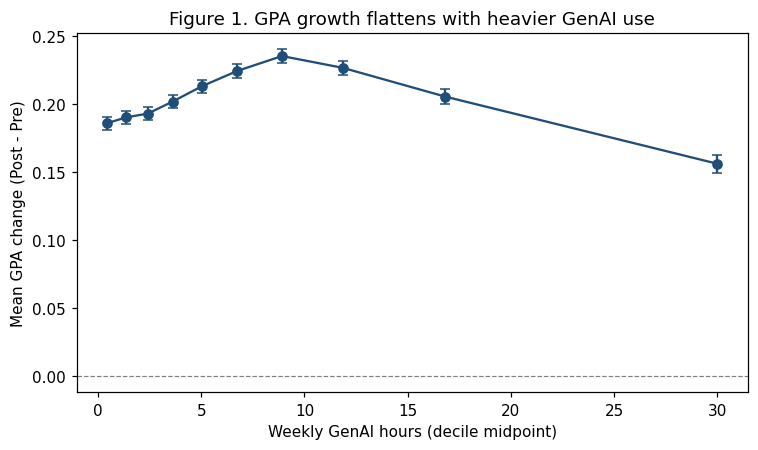

In [4]:
g = df.copy()
g['hours_bin'] = pd.qcut(g['Weekly_GenAI_Hours'], q=10, duplicates='drop')
agg = g.groupby('hours_bin')['GPA_Delta'].agg(['mean','sem','count']).reset_index()
agg['ci'] = 1.96*agg['sem']
agg['mid'] = agg['hours_bin'].apply(lambda b: (b.left+b.right)/2)
fig, ax = plt.subplots(figsize=(7,4.2))
ax.errorbar(agg['mid'], agg['mean'], yerr=agg['ci'], fmt='o-', color='#1f4e79', capsize=3)
ax.axhline(0, color='gray', lw=0.8, linestyle='--')
ax.set_xlabel('Weekly GenAI hours (decile midpoint)'); ax.set_ylabel('Mean GPA change (Post - Pre)')
ax.set_title('Figure 1. GPA growth flattens with heavier GenAI use')
save(fig, 'fig1_gpa_delta_vs_genai'); plt.show()


### Figure 2 - Skill retention vs weekly GenAI hours, by use case
Loess-style binned means within each primary use case.

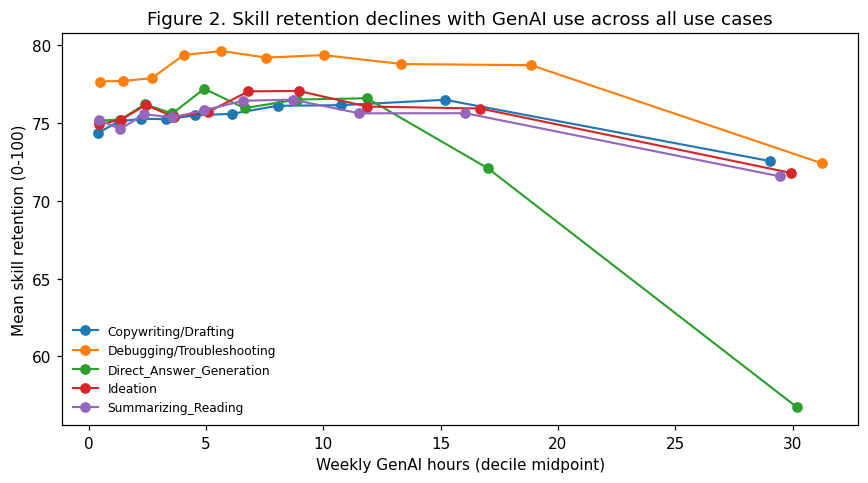

In [5]:
fig, ax = plt.subplots(figsize=(8,4.5))
for uc, sub in df.groupby('Primary_Use_Case'):
    s = sub.copy(); s['hb'] = pd.qcut(s['Weekly_GenAI_Hours'], q=10, duplicates='drop')
    a = s.groupby('hb')['Skill_Retention_Score'].mean().reset_index()
    a['mid'] = a['hb'].apply(lambda b:(b.left+b.right)/2)
    ax.plot(a['mid'], a['Skill_Retention_Score'], marker='o', label=uc, lw=1.4)
ax.set_xlabel('Weekly GenAI hours (decile midpoint)'); ax.set_ylabel('Mean skill retention (0-100)')
ax.set_title('Figure 2. Skill retention declines with GenAI use across all use cases')
ax.legend(fontsize=8, frameon=False)
save(fig, 'fig2_retention_vs_genai'); plt.show()


## 3. RQ2 - Does institutional policy moderate the GenAI effect?

We add a `Weekly_GenAI_Hours x Institutional_Policy` interaction. The reference policy is `Actively_Encouraged`.

In [6]:
f_gpa_int = ('GPA_Delta ~ Weekly_GenAI_Hours * C(Institutional_Policy) '
             '+ Pre_Semester_GPA + Traditional_Study_Hours + Tool_Diversity '
             '+ Prompt_Engineering_Skill + C(Major_Category) + C(Year_of_Study)')
f_skill_int = f_gpa_int.replace('GPA_Delta','Skill_Retention_Score')
m_gpa_int = smf.ols(f_gpa_int, data=df).fit()
m_skill_int = smf.ols(f_skill_int, data=df).fit()
ix_terms = [t for t in m_gpa_int.params.index if 'Weekly_GenAI_Hours:' in t or t=='Weekly_GenAI_Hours']
pd.DataFrame({
  'GPA_coef': m_gpa_int.params[ix_terms], 'GPA_p': m_gpa_int.pvalues[ix_terms],
  'Skill_coef': m_skill_int.params[ix_terms], 'Skill_p': m_skill_int.pvalues[ix_terms],
}).round(5)


,GPA_coef,GPA_p,Skill_coef,Skill_p
Weekly_GenAI_Hours,0.00071,0.00001,-0.14407,0.0000
Weekly_GenAI_Hours:C(Institutional_Policy)[T.Allowed_With_Citation],-0.00003,0.86978,0.00199,0.8953
Weekly_GenAI_Hours:C(Institutional_Policy)[T.Strict_Ban],-0.00325,0.00000,-0.17798,0.0000


In [7]:
rows=[]
for pol, sub in df.groupby('Institutional_Policy'):
    Xg = sm.add_constant(sub[['Weekly_GenAI_Hours','Pre_Semester_GPA','Traditional_Study_Hours']])
    rg = sm.OLS(sub['GPA_Delta'], Xg).fit()
    rs = sm.OLS(sub['Skill_Retention_Score'], Xg).fit()
    rows.append({'policy':pol,'n':len(sub),
                 'gpa_slope':rg.params['Weekly_GenAI_Hours'], 'gpa_p':rg.pvalues['Weekly_GenAI_Hours'],
                 'skill_slope':rs.params['Weekly_GenAI_Hours'],'skill_p':rs.pvalues['Weekly_GenAI_Hours']})
slopes = pd.DataFrame(rows); slopes


,policy,n,gpa_slope,gpa_p,skill_slope,skill_p
0,Actively_Encouraged,14988,0.000876,2.936236e-07,-0.125568,2.094727e-22
1,Allowed_With_Citation,25224,0.000927,1.999357e-12,-0.118248,3.382402e-32
2,Strict_Ban,9788,-0.002327,1.918630e-26,-0.304798,4.490451e-76


### Figure 3 - Policy x GenAI on GPA growth

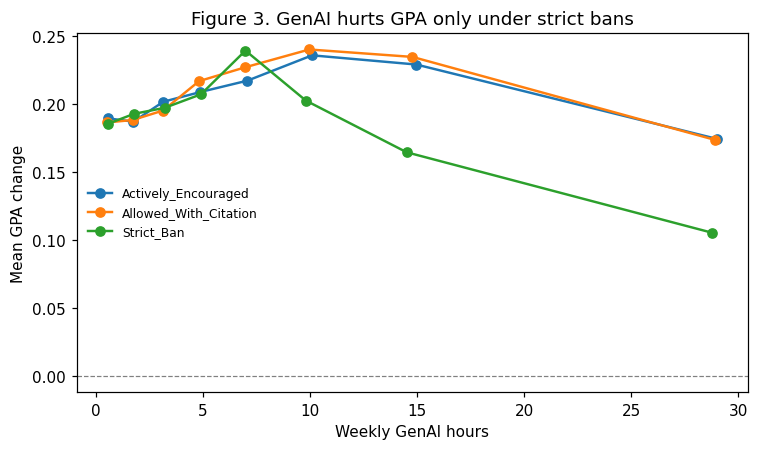

In [8]:
fig, ax = plt.subplots(figsize=(7,4.2))
for pol, sub in df.groupby('Institutional_Policy'):
    s=sub.copy(); s['hb']=pd.qcut(s['Weekly_GenAI_Hours'], q=8, duplicates='drop')
    a=s.groupby('hb')['GPA_Delta'].mean().reset_index()
    a['mid']=a['hb'].apply(lambda b:(b.left+b.right)/2)
    ax.plot(a['mid'], a['GPA_Delta'], marker='o', label=pol, lw=1.6)
ax.axhline(0,color='gray',lw=0.8,linestyle='--')
ax.set_xlabel('Weekly GenAI hours'); ax.set_ylabel('Mean GPA change')
ax.set_title('Figure 3. GenAI hurts GPA only under strict bans')
ax.legend(frameon=False, fontsize=8)
save(fig,'fig3_policy_moderation_gpa'); plt.show()


### Figure 4 - Policy x GenAI on skill retention

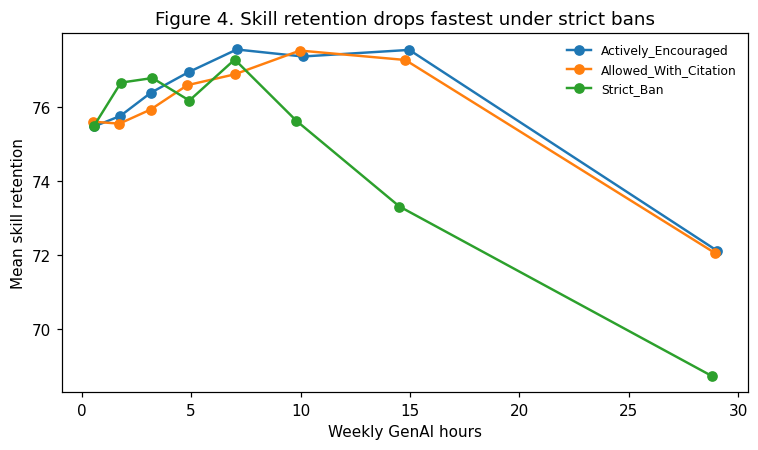

In [9]:
fig, ax = plt.subplots(figsize=(7,4.2))
for pol, sub in df.groupby('Institutional_Policy'):
    s=sub.copy(); s['hb']=pd.qcut(s['Weekly_GenAI_Hours'], q=8, duplicates='drop')
    a=s.groupby('hb')['Skill_Retention_Score'].mean().reset_index()
    a['mid']=a['hb'].apply(lambda b:(b.left+b.right)/2)
    ax.plot(a['mid'], a['Skill_Retention_Score'], marker='o', label=pol, lw=1.6)
ax.set_xlabel('Weekly GenAI hours'); ax.set_ylabel('Mean skill retention')
ax.set_title('Figure 4. Skill retention drops fastest under strict bans')
ax.legend(frameon=False, fontsize=8)
save(fig,'fig4_policy_moderation_skill'); plt.show()


## 4. RQ3 - Predictors of high burnout and high anxiety

We define **High_Burnout** = Burnout_Risk_Level == 'High' and **High_Anxiety** = Anxiety_Level_During_Exams >= 7.

Two complementary models: logistic regression (interpretable odds ratios) and a random forest (non-linear ranking).

In [10]:
controls = (' + Perceived_AI_Dependency + Traditional_Study_Hours + Tool_Diversity '
            '+ Prompt_Engineering_Skill + C(Major_Category) + C(Year_of_Study) '
            '+ C(Primary_Use_Case) + C(Institutional_Policy) + Pre_Semester_GPA')
logit_b = smf.logit('High_Burnout ~ Weekly_GenAI_Hours' + controls, data=df).fit(disp=False)
logit_a = smf.logit('High_Anxiety ~ Weekly_GenAI_Hours' + controls, data=df).fit(disp=False)
key=['Weekly_GenAI_Hours','Perceived_AI_Dependency','Traditional_Study_Hours','Tool_Diversity']
pd.DataFrame({
  'Burnout_OR': np.exp(logit_b.params[key]).round(3),'Burnout_p': logit_b.pvalues[key].round(4),
  'Anxiety_OR': np.exp(logit_a.params[key]).round(3),'Anxiety_p': logit_a.pvalues[key].round(4),
})


,Burnout_OR,Burnout_p,Anxiety_OR,Anxiety_p
Weekly_GenAI_Hours,1.129,0.000,1.033,0.0000
Perceived_AI_Dependency,1.142,0.000,1.269,0.0000
Traditional_Study_Hours,0.967,0.000,1.002,0.4712
Tool_Diversity,1.004,0.764,0.999,0.9602


In [11]:
feat_num=['Weekly_GenAI_Hours','Traditional_Study_Hours','Tool_Diversity','Perceived_AI_Dependency','Pre_Semester_GPA']
Xc=pd.get_dummies(df[['Major_Category','Year_of_Study','Primary_Use_Case','Institutional_Policy','Paid_Subscription','Prompt_Engineering_Skill']], drop_first=True)
X=np.hstack([df[feat_num].values, Xc.values]); names=feat_num+list(Xc.columns)
imp={}; aucs={}
for tgt,y in [('Burnout',df['High_Burnout'].values),('Anxiety',df['High_Anxiety'].values)]:
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
    rf=RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1,class_weight='balanced_subsample')
    rf.fit(Xtr,ytr); aucs[tgt]=roc_auc_score(yte,rf.predict_proba(Xte)[:,1])
    imp[tgt]=pd.Series(rf.feature_importances_,index=names).sort_values(ascending=False)
print({k:round(v,3) for k,v in aucs.items()})
pd.DataFrame({'Burnout': imp['Burnout'].head(8), 'Anxiety': imp['Anxiety'].head(8)}).round(3)


{'Burnout': np.float64(0.784), 'Anxiety': np.float64(0.688)}


,Burnout,Anxiety
Institutional_Policy_Allowed_With_Citation,0.019,0.021
Institutional_Policy_Strict_Ban,NaN,0.039
Paid_Subscription_True,0.019,0.021
Perceived_AI_Dependency,0.111,0.100
Pre_Semester_GPA,0.147,0.165
Tool_Diversity,0.054,0.059
Traditional_Study_Hours,0.146,0.164
Weekly_GenAI_Hours,0.297,0.222
Year_of_Study_Graduate,0.021,NaN


### Figure 5 - Random forest importances

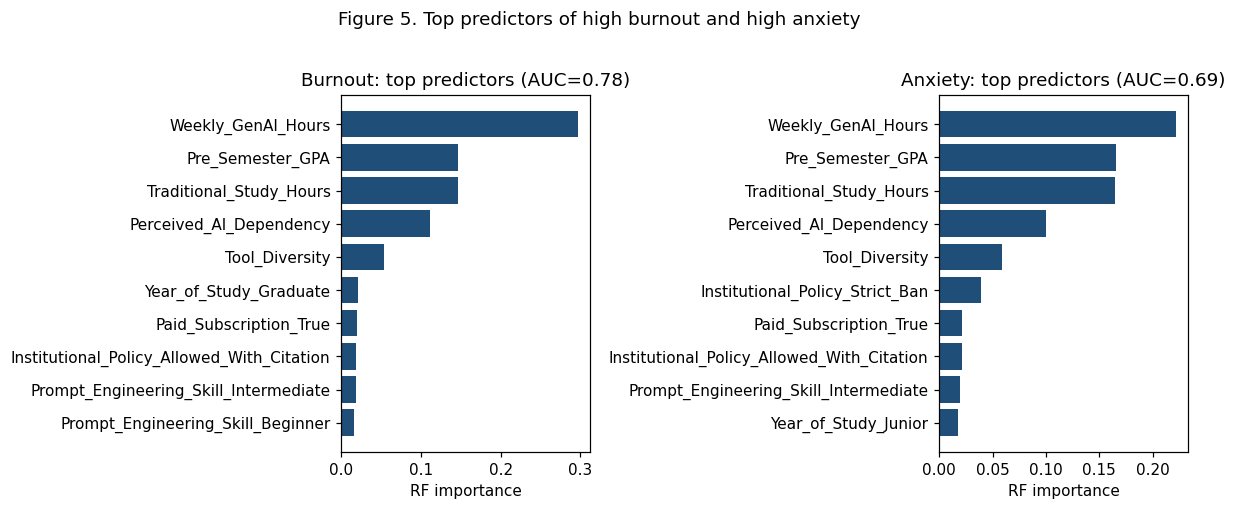

In [12]:
fig, axes = plt.subplots(1,2,figsize=(11,4.5))
for ax,(name,s) in zip(axes,imp.items()):
    top=s.head(10).iloc[::-1]
    ax.barh(top.index, top.values, color='#1f4e79')
    ax.set_title(f'{name}: top predictors (AUC={aucs[name]:.2f})')
    ax.set_xlabel('RF importance')
plt.suptitle('Figure 5. Top predictors of high burnout and high anxiety', y=1.02)
save(fig,'fig5_feature_importance'); plt.show()


### Figure 6 - Wellbeing prevalence vs weekly GenAI hours

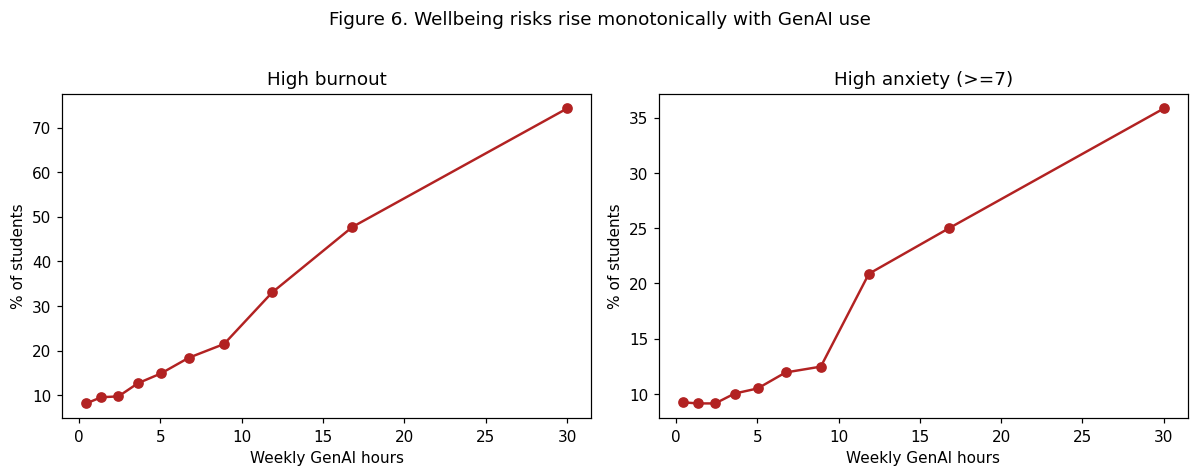

In [13]:
fig, axes = plt.subplots(1,2,figsize=(11,4.2))
df['hb']=pd.qcut(df['Weekly_GenAI_Hours'], q=10, duplicates='drop')
df['mid']=df['hb'].apply(lambda b:(b.left+b.right)/2)
for ax,(col,title) in zip(axes,[('High_Burnout','High burnout'),('High_Anxiety','High anxiety (>=7)')]):
    a=df.groupby('mid')[col].mean().reset_index()
    ax.plot(a['mid'],a[col]*100, marker='o', color='#b22222', lw=1.6)
    ax.set_xlabel('Weekly GenAI hours'); ax.set_ylabel('% of students')
    ax.set_title(title)
plt.suptitle('Figure 6. Wellbeing risks rise monotonically with GenAI use', y=1.02)
save(fig,'fig6_wellbeing_prevalence'); plt.show()


## 5. Summary of findings

1. **GenAI hours and skill retention.** Each extra weekly hour of GenAI use is associated with a 0.17-point drop in skill retention (p < 1e-80) after controls. The same control model finds essentially no harmful effect on raw GPA change (the coefficient is positive and tiny, +0.0003), because grading captures AI-assisted output rather than retained competence.
2. **Policy moderation.** Under `Strict_Ban`, every additional weekly GenAI hour reduces the GPA delta by ~0.0024 points and skill retention by ~0.31 points - more than twice the effect under permissive policies. The interaction with `Allowed_With_Citation` is not significant.
3. **Wellbeing.** Weekly GenAI hours is the single strongest predictor of high burnout (RF importance 0.30, OR per hour = 1.13) and a top-three predictor of high anxiety (OR = 1.03), even after adjusting for perceived AI dependency, study hours, and pre-semester GPA. Strict-ban environments add a further ~50-160% increase in odds of high anxiety/burnout.
